Silhouette Score: 0.6808642416167786


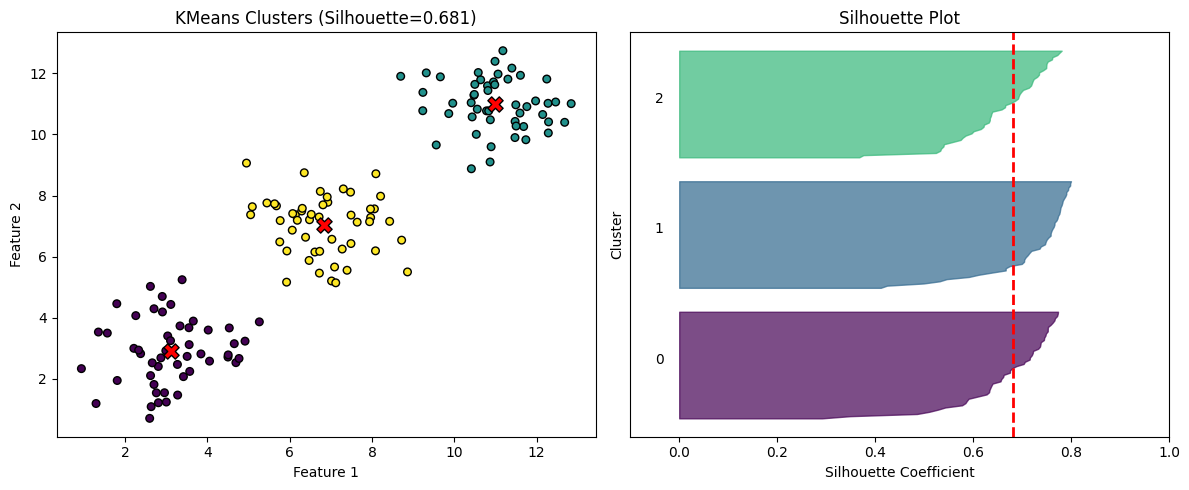

In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
np.random.seed(7)
x1 = np.random.normal(3, 1, (50, 2))   # Cluster 1 centered at 3
x2 = np.random.normal(7, 1, (50, 2))   # Cluster 2 centered at 7
x3 = np.random.normal(11, 1, (50, 2))  # Cluster 3 centered at 11
data = np.vstack((x1, x2, x3))
model = KMeans(n_clusters=3, random_state=7)
predicted_labels = model.fit_predict(data)
silhouette_val = silhouette_score(data, predicted_labels)
print("Silhouette Score:", silhouette_val)
# Plot clusters with centers
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
scatter = ax[0].scatter(data[:, 0], data[:, 1], c=predicted_labels, cmap='viridis', s=30, edgecolor='k')
centers = model.cluster_centers_
ax[0].scatter(centers[:, 0], centers[:, 1], c='red', s=120, marker='X', edgecolor='k')
ax[0].set_title(f'KMeans Clusters (Silhouette={silhouette_val:.3f})')
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')
# Silhouette plot
sample_sil = silhouette_samples(data, predicted_labels)
y_lower = 10
for cluster in range(model.n_clusters):
    cluster_sil = sample_sil[predicted_labels == cluster]
    cluster_sil.sort()
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    color = plt.cm.viridis(float(cluster) / model.n_clusters)
    ax[1].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, facecolor=color, edgecolor=color, alpha=0.7)
    ax[1].text(-0.05, y_lower + size / 2, str(cluster))
    y_lower = y_upper + 10
ax[1].axvline(silhouette_val, color='red', linestyle='--', linewidth=2)
ax[1].set_title('Silhouette Plot')
ax[1].set_xlabel('Silhouette Coefficient')
ax[1].set_ylabel('Cluster')
ax[1].set_yticks([])
ax[1].set_xlim([-0.1, 1])
plt.tight_layout()
plt.show()
